# 🔲 Notebook 7 — Matrice de Confusion
**ISIC Project | Segmentation de Lésions Cutanées**

Ce notebook génère **3 types de matrices de confusion** :

| Type | Description |
|------|-------------|
| **Type 1** | Matrice globale sur tout le jeu de test (tous les pixels) |
| **Type 2** | Matrice par image (une ligne = une image) |
| **Type 3** | Visualisation spatiale pixel par pixel (TP/TN/FP/FN sur l'image) |

---

### 🔲 Rappel — Qu'est-ce qu'une matrice de confusion en segmentation ?

Pour la segmentation binaire, chaque pixel est une prédiction indépendante :

```
                    RÉALITÉ
                Lésion (1)  |  Sain (0)
           ┌───────────────────────────────┐
Lésion (1) │  TP (Vrai +)  │  FP (Faux +) │
PRÉDICTION ├───────────────────────────────┤
  Sain (0) │  FN (Faux -)  │  TN (Vrai -) │
           └───────────────────────────────┘
```
- **TP** : prédit lésion  → vraiment une lésion ✅
- **TN** : prédit sain    → vraiment sain       ✅
- **FP** : prédit lésion  → c'est sain          ❌ fausse alarme
- **FN** : prédit sain    → c'est une lésion    ❌ lésion manquée (dangereux !)

## ⚙️ Étape 1 — Setup & Connexion Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
from pathlib import Path

PROJECT_PATH  = '/content/drive/MyDrive/ISIC_Project'
IMAGES_PATH   = os.path.join(PROJECT_PATH, 'data', 'Images')
MASQUES_PATH  = os.path.join(PROJECT_PATH, 'data', 'Masques')
OUTPUTS_PATH  = os.path.join(PROJECT_PATH, 'outputs')
MODEL_PATH    = os.path.join(OUTPUTS_PATH, 'best_unet_isic.pth')
CM_PATH       = os.path.join(OUTPUTS_PATH, 'confusion_matrix')
os.makedirs(CM_PATH, exist_ok=True)

if os.path.exists(MODEL_PATH):
    print(f'✅ Modèle trouvé ({os.path.getsize(MODEL_PATH)/1024/1024:.1f} MB)')
else:
    print('❌ Modèle introuvable — exécute d\'abord le notebook 03 !')

Mounted at /content/drive
✅ Modèle trouvé (118.5 MB)


## 📦 Étape 2 — Installations & Imports

In [2]:
!pip install -q albumentations opencv-python-headless scikit-learn seaborn

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from tqdm import tqdm
import json
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports OK | Device : {device}')

✅ Imports OK | Device : cuda


## 🧠 Étape 3 — Chargement du modèle

In [3]:
# ── Architecture U-Net ────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super().__init__()
        self.downs, self.ups = nn.ModuleList(), nn.ModuleList()
        self.pool = nn.MaxPool2d(2,2)
        for f in features:
            self.downs.append(DoubleConv(in_channels, f)); in_channels = f
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, 2))
            self.ups.append(DoubleConv(f*2, f))
        self.final = nn.Conv2d(features[0], out_channels, 1)
    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x); skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x); skip = skips[i//2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = self.ups[i+1](torch.cat([skip, x], dim=1))
        return self.final(x)

model = UNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# ── Transform & Dataset ───────────────────────────────────────────────────────
IMG_SIZE = 256
THRESHOLD = 0.5

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

class ISICDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths; self.mask_paths = mask_paths; self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img  = cv2.cvtColor(cv2.imread(str(self.image_paths[idx])), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            out = self.transform(image=img, mask=mask)
            img = out['image']; mask = out['mask'].unsqueeze(0)
        return img.float(), mask.float()

# ── Chargement du jeu de test ────────────────────────────────────────────────
IMAGE_EXTENSIONS = {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}
all_images = sorted([p for p in Path(IMAGES_PATH).glob('*.*') if p.suffix.lower() in IMAGE_EXTENSIONS])
all_masks  = sorted([p for p in Path(MASQUES_PATH).glob('*.*') if p.suffix.lower() in IMAGE_EXTENSIONS])
assert len(all_images) == len(all_masks)

_, temp_imgs, _, temp_msks = train_test_split(all_images, all_masks, test_size=0.3, random_state=42)
_, test_imgs, _, test_msks = train_test_split(temp_imgs, temp_msks, test_size=0.5, random_state=42)

test_loader = DataLoader(
    ISICDataset(test_imgs, test_msks, val_transform),
    batch_size=8, shuffle=False, num_workers=2)

print(f'✅ Modèle chargé | Test set : {len(test_imgs)} images | {len(test_loader)} batchs')

✅ Modèle chargé | Test set : 390 images | 49 batchs


---
## 🔲 TYPE 1 — Matrice de confusion globale
*(accumule tous les pixels de toutes les images du test set)*

In [4]:
# ── Accumulation TP / TN / FP / FN sur tout le test set ─────────────────────
total_tp = total_tn = total_fp = total_fn = 0

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Calcul matrice de confusion globale'):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        pred_bin = (torch.sigmoid(preds) > THRESHOLD).float()

        total_tp += int((pred_bin * masks).sum().item())
        total_tn += int(((1-pred_bin) * (1-masks)).sum().item())
        total_fp += int((pred_bin * (1-masks)).sum().item())
        total_fn += int(((1-pred_bin) * masks).sum().item())

total_pixels = total_tp + total_tn + total_fp + total_fn
smooth = 1e-6

# ── Métriques dérivées ───────────────────────────────────────────────────────
accuracy     = (total_tp + total_tn) / total_pixels
dice         = (2*total_tp + smooth) / (2*total_tp + total_fp + total_fn + smooth)
iou          = (total_tp + smooth)   / (total_tp + total_fp + total_fn + smooth)
precision    = (total_tp + smooth)   / (total_tp + total_fp + smooth)
recall       = (total_tp + smooth)   / (total_tp + total_fn + smooth)
f1           = (2*precision*recall)  / (precision + recall + smooth)
specificity  = (total_tn + smooth)   / (total_tn + total_fp + smooth)
fpr          = total_fp / (total_fp + total_tn + smooth)  # Taux de fausse alarme
fnr          = total_fn / (total_fn + total_tp + smooth)  # Taux de manqués

print(f'\n📊 Pixels totaux analysés : {total_pixels:,}')
print(f'   TP (Vrais Positifs)  : {total_tp:,} ({total_tp/total_pixels*100:.2f}%)')
print(f'   TN (Vrais Négatifs)  : {total_tn:,} ({total_tn/total_pixels*100:.2f}%)')
print(f'   FP (Faux Positifs)   : {total_fp:,} ({total_fp/total_pixels*100:.2f}%)')
print(f'   FN (Faux Négatifs)   : {total_fn:,} ({total_fn/total_pixels*100:.2f}%)')

Calcul matrice de confusion globale: 100%|██████████| 49/49 [11:24<00:00, 13.96s/it]


📊 Pixels totaux analysés : 25,559,040
   TP (Vrais Positifs)  : 4,446,831 (17.40%)
   TN (Vrais Négatifs)  : 19,814,652 (77.53%)
   FP (Faux Positifs)   : 417,458 (1.63%)
   FN (Faux Négatifs)   : 880,099 (3.44%)


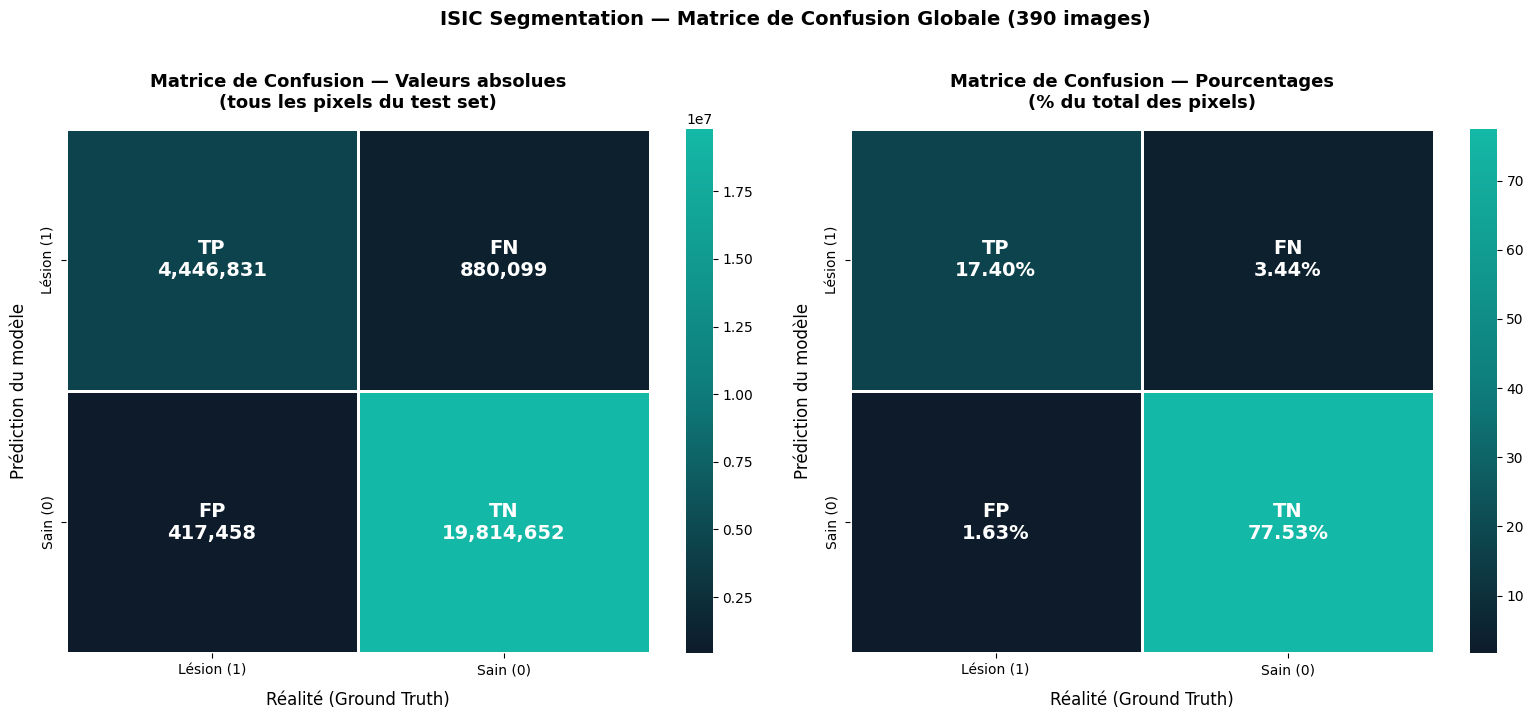

💾 Sauvegardée : /content/drive/MyDrive/ISIC_Project/outputs/confusion_matrix/confusion_matrix_globale.png


In [5]:
# ── Affichage de la matrice de confusion ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Matrice 1 : valeurs absolues ─────────────────────────────────────────────
cm_abs = np.array([
    [total_tp, total_fn],
    [total_fp, total_tn]
])
labels_abs = [
    [f'TP\n{total_tp:,}', f'FN\n{total_fn:,}'],
    [f'FP\n{total_fp:,}', f'TN\n{total_tn:,}']
]

# Colormap personnalisée
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#0D1B2A', '#0E7C7B', '#14B8A6'], N=256)

sns.heatmap(
    cm_abs,
    annot=np.array(labels_abs),
    fmt='',
    cmap=custom_cmap,
    ax=axes[0],
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'},
    xticklabels=['Lésion (1)', 'Sain (0)'],
    yticklabels=['Lésion (1)', 'Sain (0)']
)
axes[0].set_title('Matrice de Confusion — Valeurs absolues\n(tous les pixels du test set)',
                  fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Réalité (Ground Truth)',  fontsize=12, labelpad=10)
axes[0].set_ylabel('Prédiction du modèle',    fontsize=12, labelpad=10)

# ── Matrice 2 : pourcentages normalisés ──────────────────────────────────────
cm_pct = np.array([
    [total_tp/total_pixels*100, total_fn/total_pixels*100],
    [total_fp/total_pixels*100, total_tn/total_pixels*100]
])
labels_pct = [
    [f'TP\n{cm_pct[0,0]:.2f}%', f'FN\n{cm_pct[0,1]:.2f}%'],
    [f'FP\n{cm_pct[1,0]:.2f}%', f'TN\n{cm_pct[1,1]:.2f}%']
]

sns.heatmap(
    cm_pct,
    annot=np.array(labels_pct),
    fmt='',
    cmap=custom_cmap,
    ax=axes[1],
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'},
    xticklabels=['Lésion (1)', 'Sain (0)'],
    yticklabels=['Lésion (1)', 'Sain (0)']
)
axes[1].set_title('Matrice de Confusion — Pourcentages\n(% du total des pixels)',
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Réalité (Ground Truth)',  fontsize=12, labelpad=10)
axes[1].set_ylabel('Prédiction du modèle',    fontsize=12, labelpad=10)

plt.suptitle(f'ISIC Segmentation — Matrice de Confusion Globale ({len(test_imgs)} images)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = os.path.join(CM_PATH, 'confusion_matrix_globale.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Sauvegardée : {save_path}')

In [6]:
# ── Tableau récapitulatif des métriques dérivées ─────────────────────────────
print('\n' + '='*65)
print('📊  MÉTRIQUES DÉRIVÉES DE LA MATRICE DE CONFUSION')
print('='*65)
metrics_table = [
    ('Accuracy',           accuracy,    '(TP+TN)/Total    — ⚠️ Gonflée par TN'),
    ('Dice Score (F1)',    dice,        '2×TP/(2TP+FP+FN) — ⭐ Métrique principale'),
    ('IoU (Jaccard)',      iou,         'TP/(TP+FP+FN)    — Plus stricte que Dice'),
    ('Précision',         precision,   'TP/(TP+FP)       — Qualité prédictions +'),
    ('Recall (Sensib.)',  recall,      'TP/(TP+FN)       — Lésions détectées'),
    ('Spécificité',       specificity, 'TN/(TN+FP)       — Pixels sains corrects'),
    ('Taux Fausse Alarme',fpr,         'FP/(FP+TN)       — Pixels sains mal classés'),
    ('Taux Manqués (FNR)',fnr,         'FN/(FN+TP)       — Lésions manquées'),
]
for name, val, desc in metrics_table:
    print(f'  {name:<22} {val:.4f}   {desc}')
print('='*65)
print(f'\n  TP={total_tp:,}  TN={total_tn:,}  FP={total_fp:,}  FN={total_fn:,}')
print(f'  Total pixels analysés : {total_pixels:,}')


📊  MÉTRIQUES DÉRIVÉES DE LA MATRICE DE CONFUSION
  Accuracy               0.9492   (TP+TN)/Total    — ⚠️ Gonflée par TN
  Dice Score (F1)        0.8727   2×TP/(2TP+FP+FN) — ⭐ Métrique principale
  IoU (Jaccard)          0.7741   TP/(TP+FP+FN)    — Plus stricte que Dice
  Précision              0.9142   TP/(TP+FP)       — Qualité prédictions +
  Recall (Sensib.)       0.8348   TP/(TP+FN)       — Lésions détectées
  Spécificité            0.9794   TN/(TN+FP)       — Pixels sains corrects
  Taux Fausse Alarme     0.0206   FP/(FP+TN)       — Pixels sains mal classés
  Taux Manqués (FNR)     0.1652   FN/(FN+TP)       — Lésions manquées

  TP=4,446,831  TN=19,814,652  FP=417,458  FN=880,099
  Total pixels analysés : 25,559,040


---
## 🔲 TYPE 2 — Matrice de confusion par image
*(une ligne = une image du test set)*

In [7]:
infer_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

per_image_cms = []
smooth = 1e-6

for img_path, msk_path in tqdm(zip(test_imgs, test_msks),
                                total=len(test_imgs), desc='CM par image'):
    # Chargement
    img  = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize((mask > 127).astype(np.float32),
                      (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    # Prédiction
    tensor = infer_transform(image=img)['image'].unsqueeze(0).float().to(device)
    with torch.no_grad():
        pred = (torch.sigmoid(model(tensor)) > THRESHOLD).float().squeeze().cpu().numpy()

    # Calcul
    tp = int((pred * mask).sum())
    tn = int(((1-pred) * (1-mask)).sum())
    fp = int((pred * (1-mask)).sum())
    fn = int(((1-pred) * mask).sum())
    total = tp + tn + fp + fn

    dice_i = (2*tp+smooth)/(2*tp+fp+fn+smooth)
    acc_i  = (tp+tn)/(total+smooth)
    prec_i = (tp+smooth)/(tp+fp+smooth)
    rec_i  = (tp+smooth)/(tp+fn+smooth)

    per_image_cms.append({
        'filename' : img_path.name,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'accuracy' : acc_i,
        'dice'     : dice_i,
        'precision': prec_i,
        'recall'   : rec_i,
        'lesion_pct': float(mask.sum()/mask.size*100)
    })

# Trier par Dice Score décroissant
per_image_cms.sort(key=lambda x: x['dice'], reverse=True)
print(f'✅ {len(per_image_cms)} matrices calculées')

CM par image: 100%|██████████| 390/390 [01:34<00:00,  4.12it/s]

✅ 390 matrices calculées


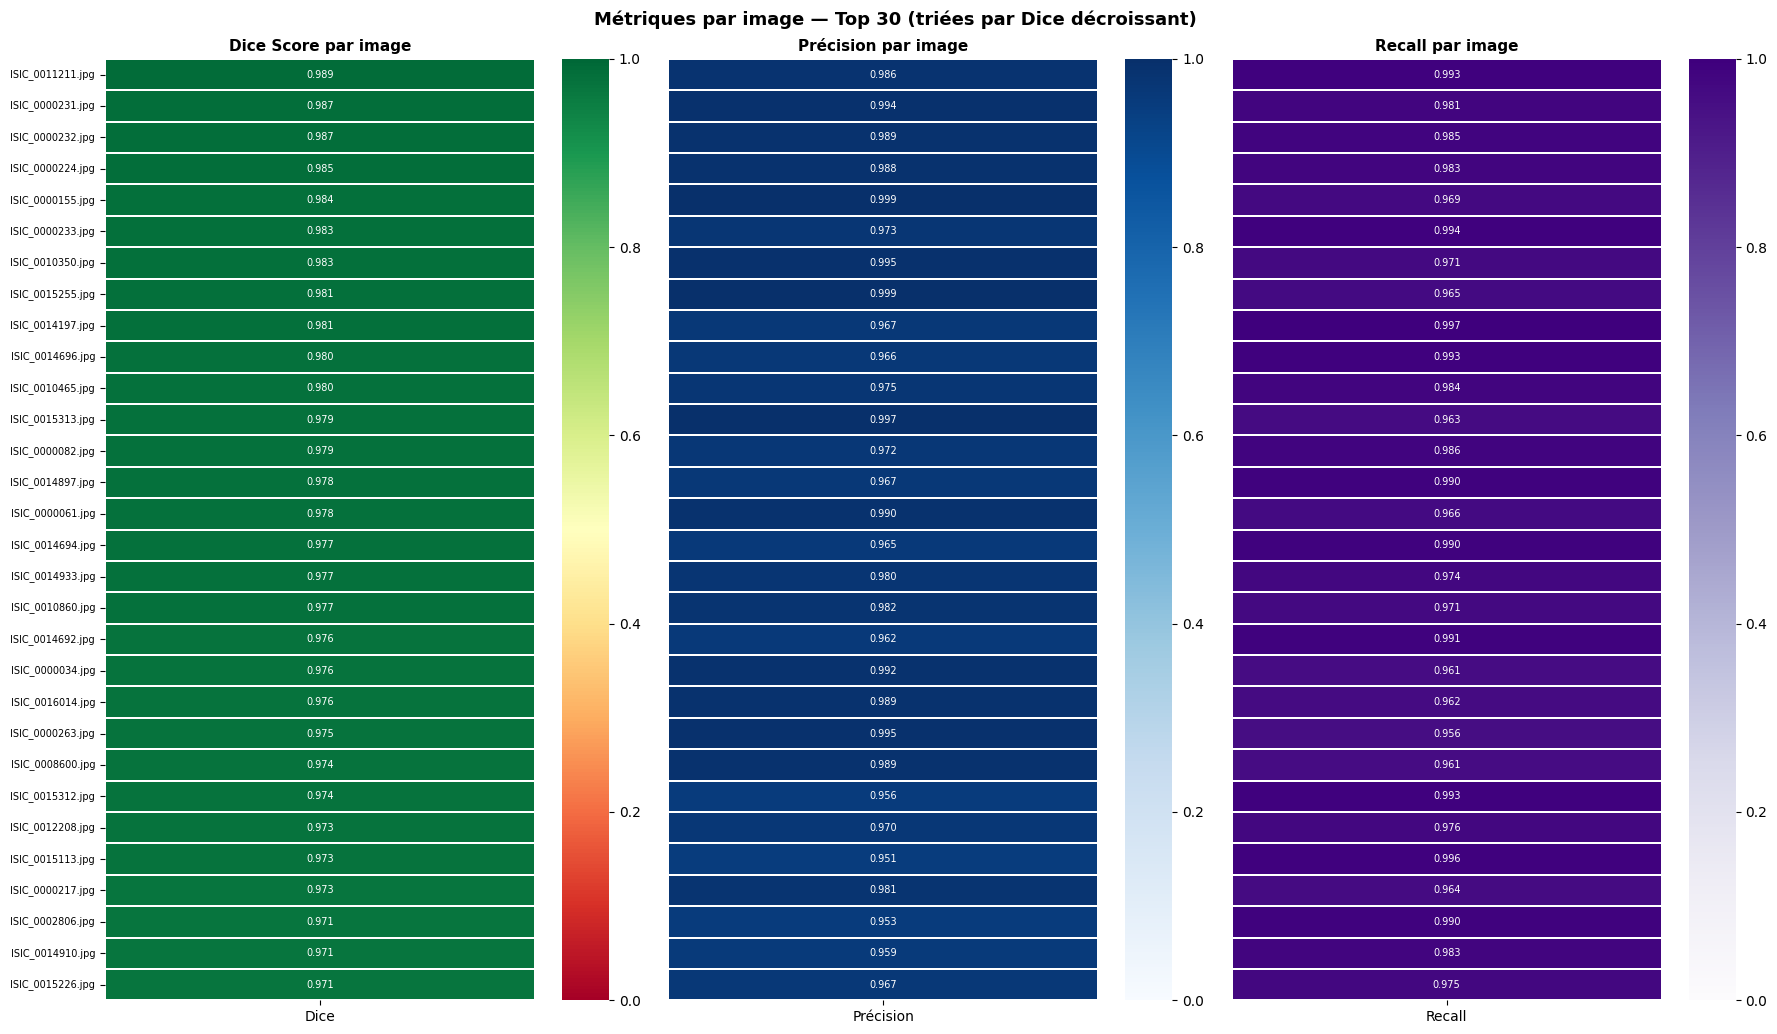

💾 Sauvegardée : /content/drive/MyDrive/ISIC_Project/outputs/confusion_matrix/confusion_matrix_par_image.png


In [8]:
# ── Heatmap des TP/FP/FN par image ──────────────────────────────────────────
N_SHOW = min(30, len(per_image_cms))  # Afficher les 30 premières
sample = per_image_cms[:N_SHOW]

fig, axes = plt.subplots(1, 3, figsize=(18, max(6, N_SHOW * 0.35)))

for ax_idx, (key, title, cmap, vmin, vmax) in enumerate([
    ('dice',      'Dice Score par image',     'RdYlGn', 0, 1),
    ('precision', 'Précision par image',      'Blues',  0, 1),
    ('recall',    'Recall par image',         'Purples', 0, 1),
]):
    values  = np.array([[r[key]] for r in sample])
    filenames = [r['filename'][:22] + '…' if len(r['filename']) > 22
                 else r['filename'] for r in sample]

    sns.heatmap(
        values, annot=True, fmt='.3f',
        cmap=cmap, vmin=vmin, vmax=vmax,
        ax=axes[ax_idx], linewidths=0.3, linecolor='white',
        yticklabels=filenames if ax_idx == 0 else False,
        xticklabels=[title.split()[0]],
        annot_kws={'size': 7}
    )
    axes[ax_idx].set_title(title, fontsize=11, fontweight='bold')
    if ax_idx == 0:
        axes[ax_idx].tick_params(axis='y', labelsize=7)

plt.suptitle(f'Métriques par image — Top {N_SHOW} (triées par Dice décroissant)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(CM_PATH, 'confusion_matrix_par_image.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Sauvegardée : {save_path}')

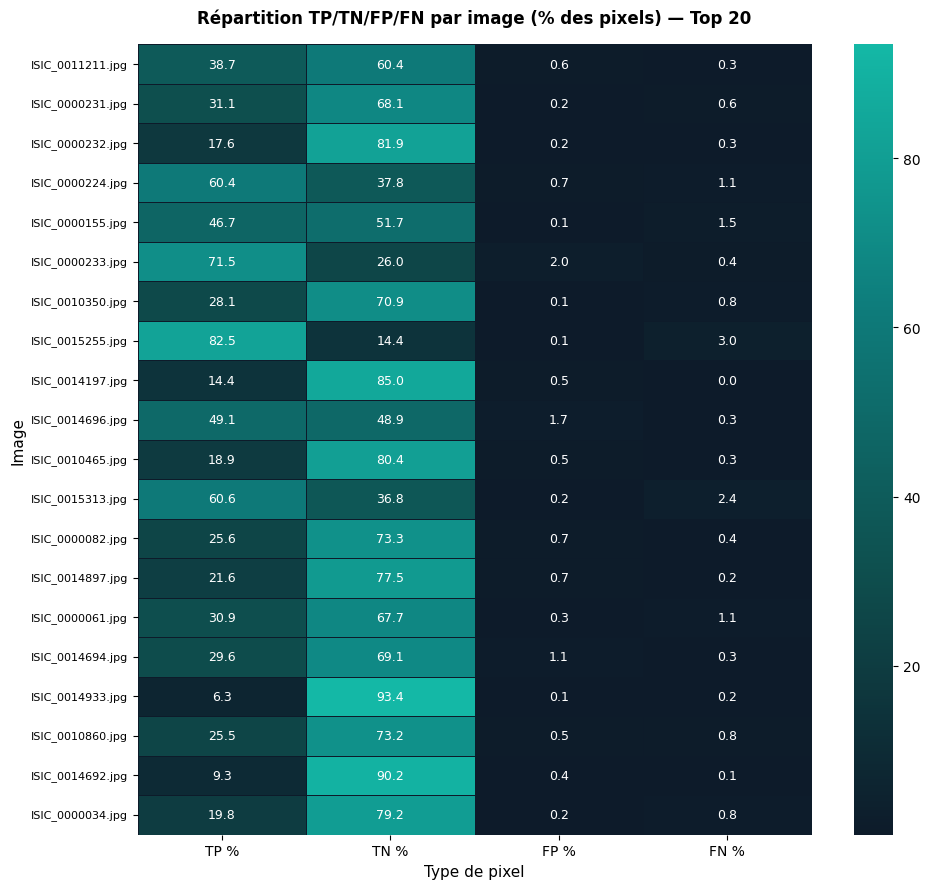

💾 Sauvegardée : /content/drive/MyDrive/ISIC_Project/outputs/confusion_matrix/confusion_matrix_tp_tn_fp_fn.png


In [9]:
# ── Matrice TP/TN/FP/FN normalisée par image (heatmap) ──────────────────────
N_SHOW2 = min(20, len(per_image_cms))
sample2 = per_image_cms[:N_SHOW2]

# Construire la matrice [N_images x 4] (TP, TN, FP, FN en %)
cm_matrix = np.array([
    [
        r['tp'] / (r['tp']+r['tn']+r['fp']+r['fn']) * 100,
        r['tn'] / (r['tp']+r['tn']+r['fp']+r['fn']) * 100,
        r['fp'] / (r['tp']+r['tn']+r['fp']+r['fn']) * 100,
        r['fn'] / (r['tp']+r['tn']+r['fp']+r['fn']) * 100,
    ]
    for r in sample2
])

filenames2 = [r['filename'][:20] + '…' if len(r['filename']) > 20
              else r['filename'] for r in sample2]

fig, ax = plt.subplots(figsize=(10, max(6, N_SHOW2 * 0.45)))
colors_cm = ['#0E7C7B', '#334155', '#dc2626', '#1d4ed8']  # TP, TN, FP, FN
custom_cm = mcolors.LinearSegmentedColormap.from_list(
    'cm', ['#0D1B2A', '#0E4F4E', '#0E7C7B', '#14B8A6'], N=256)

sns.heatmap(
    cm_matrix,
    annot=True, fmt='.1f',
    cmap=custom_cm,
    ax=ax,
    linewidths=0.5, linecolor='#0D1B2A',
    yticklabels=filenames2,
    xticklabels=['TP %', 'TN %', 'FP %', 'FN %'],
    annot_kws={'size': 9}
)
ax.set_title(
    f'Répartition TP/TN/FP/FN par image (% des pixels) — Top {N_SHOW2}',
    fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Type de pixel', fontsize=11)
ax.set_ylabel('Image', fontsize=11)

plt.tight_layout()
save_path = os.path.join(CM_PATH, 'confusion_matrix_tp_tn_fp_fn.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Sauvegardée : {save_path}')

---
## 🔲 TYPE 3 — Visualisation spatiale TP/TN/FP/FN
*(carte colorée pixel par pixel sur l'image originale)*

In [10]:
import random

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def visualize_spatial_cm(img_path, msk_path, threshold=0.5, save_path=None):
    """
    Affiche la matrice de confusion spatiale pour une image :
    - Vert  = TP  (prédit lésion,  c'est une lésion)
    - Gris  = TN  (prédit sain,    c'est sain)
    - Rouge = FP  (prédit lésion,  c'est sain)   ← fausse alarme
    - Bleu  = FN  (prédit sain,    c'est lésion) ← manqué !
    """
    # Chargement
    img  = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    mask_raw = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize((mask_raw > 127).astype(np.float32),
                      (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    # Prédiction
    tensor = infer_transform(image=img)['image'].unsqueeze(0).float().to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()
        pred = (prob > threshold).astype(np.float32)

    # Image redimensionnée pour affichage
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # ── Carte spatiale TP/TN/FP/FN ──────────────────────────────────────────
    spatial_cm = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    tp_mask = (pred == 1) & (mask == 1)
    tn_mask = (pred == 0) & (mask == 0)
    fp_mask = (pred == 1) & (mask == 0)
    fn_mask = (pred == 0) & (mask == 1)

    spatial_cm[tp_mask] = [0,   200,  0  ]  # Vert vif  = TP
    spatial_cm[tn_mask] = [30,  30,   50 ]  # Gris foncé = TN
    spatial_cm[fp_mask] = [220, 50,   50 ]  # Rouge     = FP
    spatial_cm[fn_mask] = [50,  50,   220]  # Bleu vif  = FN

    # ── Overlay image + carte ────────────────────────────────────────────────
    overlay = cv2.addWeighted(img_r, 0.4, spatial_cm, 0.6, 0)

    # ── Statistiques ─────────────────────────────────────────────────────────
    tp_c = tp_mask.sum(); tn_c = tn_mask.sum()
    fp_c = fp_mask.sum(); fn_c = fn_mask.sum()
    total = tp_c + tn_c + fp_c + fn_c
    s = 1e-6
    dice_i = (2*tp_c+s)/(2*tp_c+fp_c+fn_c+s)
    prec_i = (tp_c+s)/(tp_c+fp_c+s)
    rec_i  = (tp_c+s)/(tp_c+fn_c+s)
    acc_i  = (tp_c+tn_c)/total

    # ── Figure ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    axes[0,0].imshow(img_r)
    axes[0,0].set_title('Image originale', fontweight='bold', fontsize=12)
    axes[0,0].axis('off')

    axes[0,1].imshow(mask, cmap='gray')
    axes[0,1].set_title('Masque réel (vérité terrain)', fontweight='bold', fontsize=12)
    axes[0,1].axis('off')

    axes[0,2].imshow(pred, cmap='gray')
    axes[0,2].set_title(f'Masque prédit (seuil={threshold})', fontweight='bold', fontsize=12)
    axes[0,2].axis('off')

    axes[1,0].imshow(prob, cmap='jet', vmin=0, vmax=1)
    axes[1,0].set_title('Carte de probabilité', fontweight='bold', fontsize=12)
    axes[1,0].axis('off')
    plt.colorbar(axes[1,0].images[0], ax=axes[1,0], fraction=0.046, pad=0.04)

    axes[1,1].imshow(spatial_cm)
    legend_patches = [
        mpatches.Patch(color=(0,200/255,0),     label=f'TP — {tp_c:,} px ({tp_c/total*100:.1f}%)'),
        mpatches.Patch(color=(30/255,30/255,50/255),  label=f'TN — {tn_c:,} px ({tn_c/total*100:.1f}%)'),
        mpatches.Patch(color=(220/255,50/255,50/255), label=f'FP — {fp_c:,} px ({fp_c/total*100:.1f}%)'),
        mpatches.Patch(color=(50/255,50/255,220/255), label=f'FN — {fn_c:,} px ({fn_c/total*100:.1f}%)'),
    ]
    axes[1,1].legend(handles=legend_patches, loc='lower right', fontsize=9,
                     framealpha=0.85)
    axes[1,1].set_title('Carte spatiale TP/TN/FP/FN', fontweight='bold', fontsize=12)
    axes[1,1].axis('off')

    axes[1,2].imshow(overlay)
    axes[1,2].set_title('Overlay (image + carte)', fontweight='bold', fontsize=12)
    axes[1,2].axis('off')

    # Mini matrice de confusion dans le titre
    suptitle = (
        f'{img_path.name}\n'
        f'Accuracy={acc_i:.3f}  Dice={dice_i:.3f}  '
        f'Précision={prec_i:.3f}  Recall={rec_i:.3f}'
    )
    plt.suptitle(suptitle, fontsize=12, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Sauvegardée : {save_path}')
    plt.show()

    # Mini matrice texte
    print(f'\n🔲 Matrice de confusion — {img_path.name}')
    print(f'              Réalité Lésion  │  Réalité Sain')
    print(f'  Prédit Lésion  {tp_c:>10,}   │  {fp_c:>10,}')
    print(f'  Prédit Sain    {fn_c:>10,}   │  {tn_c:>10,}')

    return {'tp':tp_c, 'tn':tn_c, 'fp':fp_c, 'fn':fn_c,
            'dice':dice_i, 'accuracy':acc_i, 'precision':prec_i, 'recall':rec_i}

print('✅ Fonction de visualisation spatiale prête !')

✅ Fonction de visualisation spatiale prête !


🏆 Meilleure prédiction : ISIC_0011211.jpg
   Dice = 0.9893
💾 Sauvegardée : /content/drive/MyDrive/ISIC_Project/outputs/confusion_matrix/cm_spatial_meilleure.png


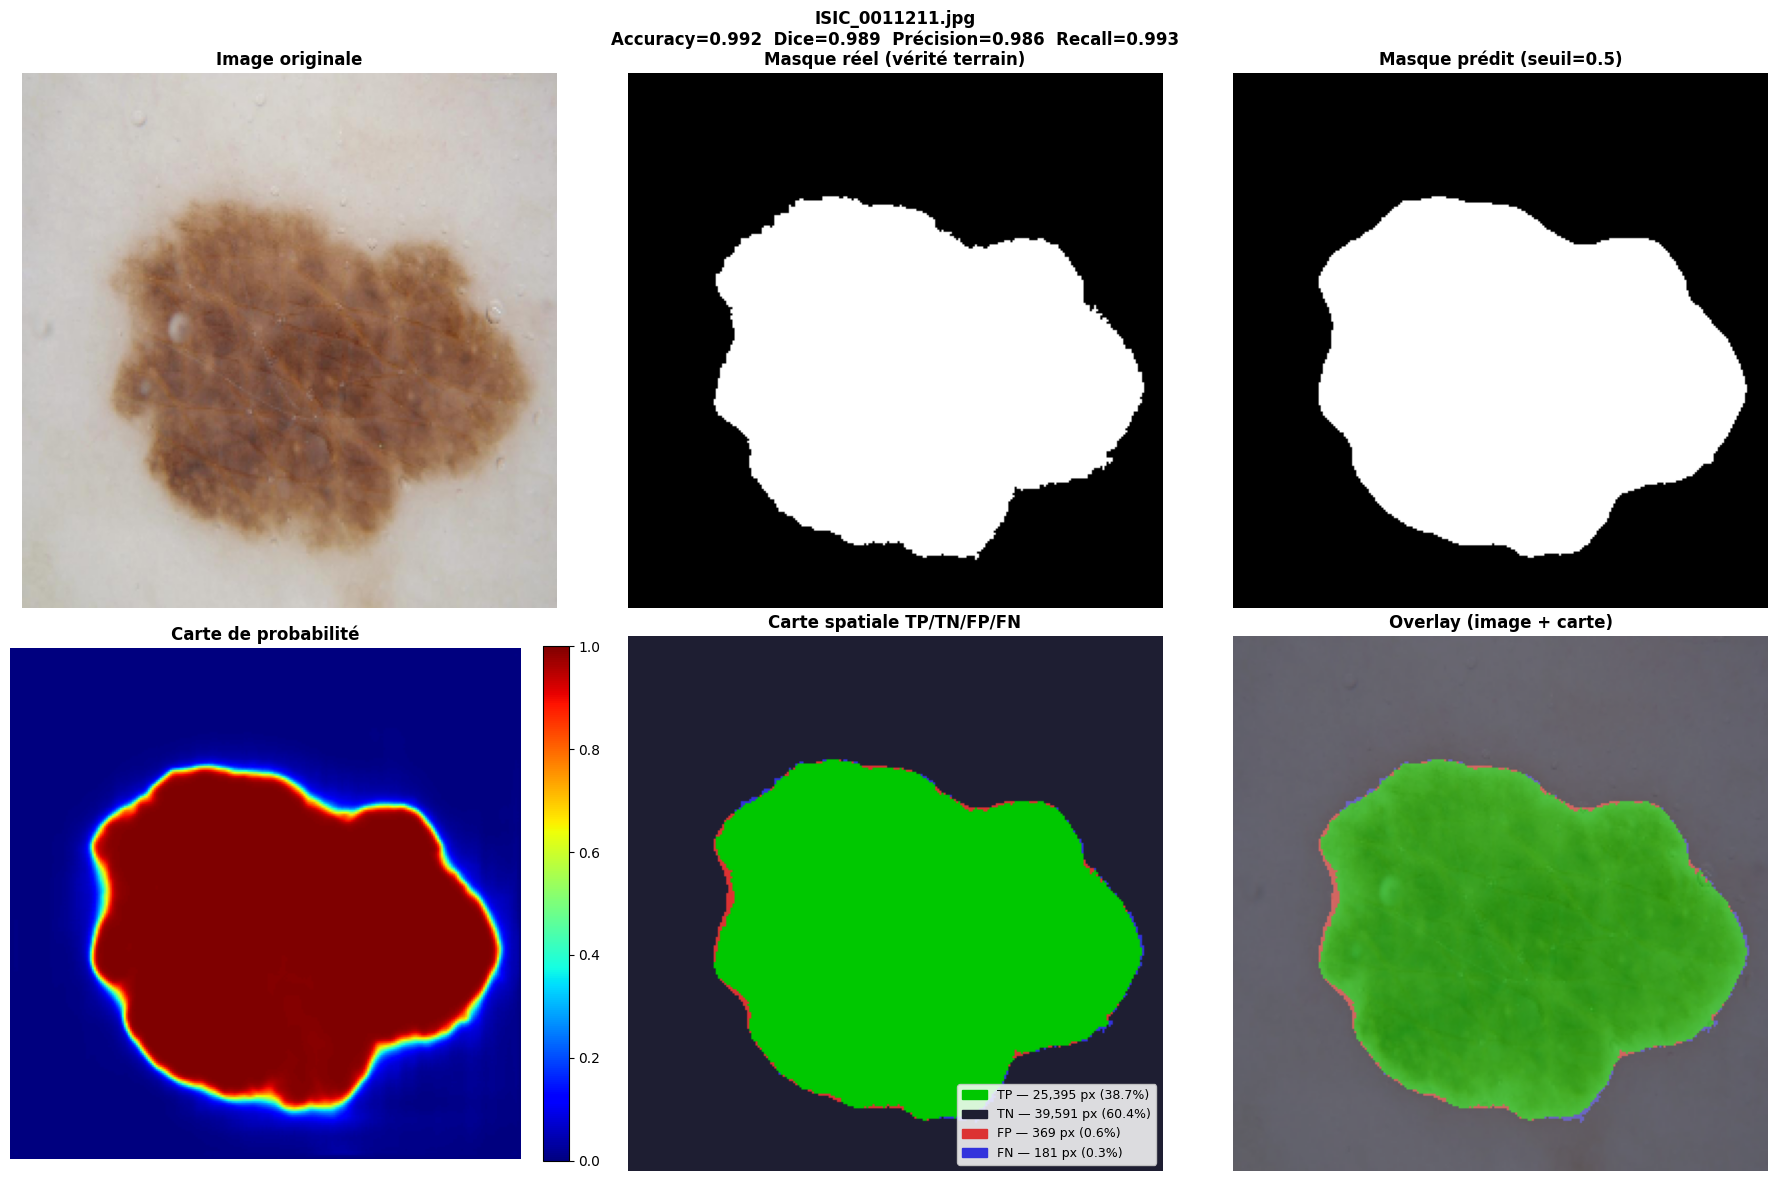


🔲 Matrice de confusion — ISIC_0011211.jpg
              Réalité Lésion  │  Réalité Sain
  Prédit Lésion      25,395   │         369
  Prédit Sain           181   │      39,591


{'tp': np.int64(25395),
 'tn': np.int64(39591),
 'fp': np.int64(369),
 'fn': np.int64(181),
 'dice': np.float64(0.9892871055709138),
 'accuracy': np.float64(0.991607666015625),
 'precision': np.float64(0.9856776898002765),
 'recall': np.float64(0.9929230528623348)}

In [11]:
# ── Afficher 4 exemples variés ───────────────────────────────────────────────

# 1. Meilleure prédiction (Dice le plus haut)
best  = per_image_cms[0]
best_idx = next(i for i, p in enumerate(test_imgs) if p.name == best['filename'])

print('=' * 60)
print(f'🏆 Meilleure prédiction : {best["filename"]}')
print(f'   Dice = {best["dice"]:.4f}')
print('=' * 60)
visualize_spatial_cm(
    test_imgs[best_idx], test_msks[best_idx],
    save_path=os.path.join(CM_PATH, 'cm_spatial_meilleure.png')
)

❌ Cas difficile : ISIC_0012898.jpg
   Dice = 0.0000
💾 Sauvegardée : /content/drive/MyDrive/ISIC_Project/outputs/confusion_matrix/cm_spatial_difficile.png


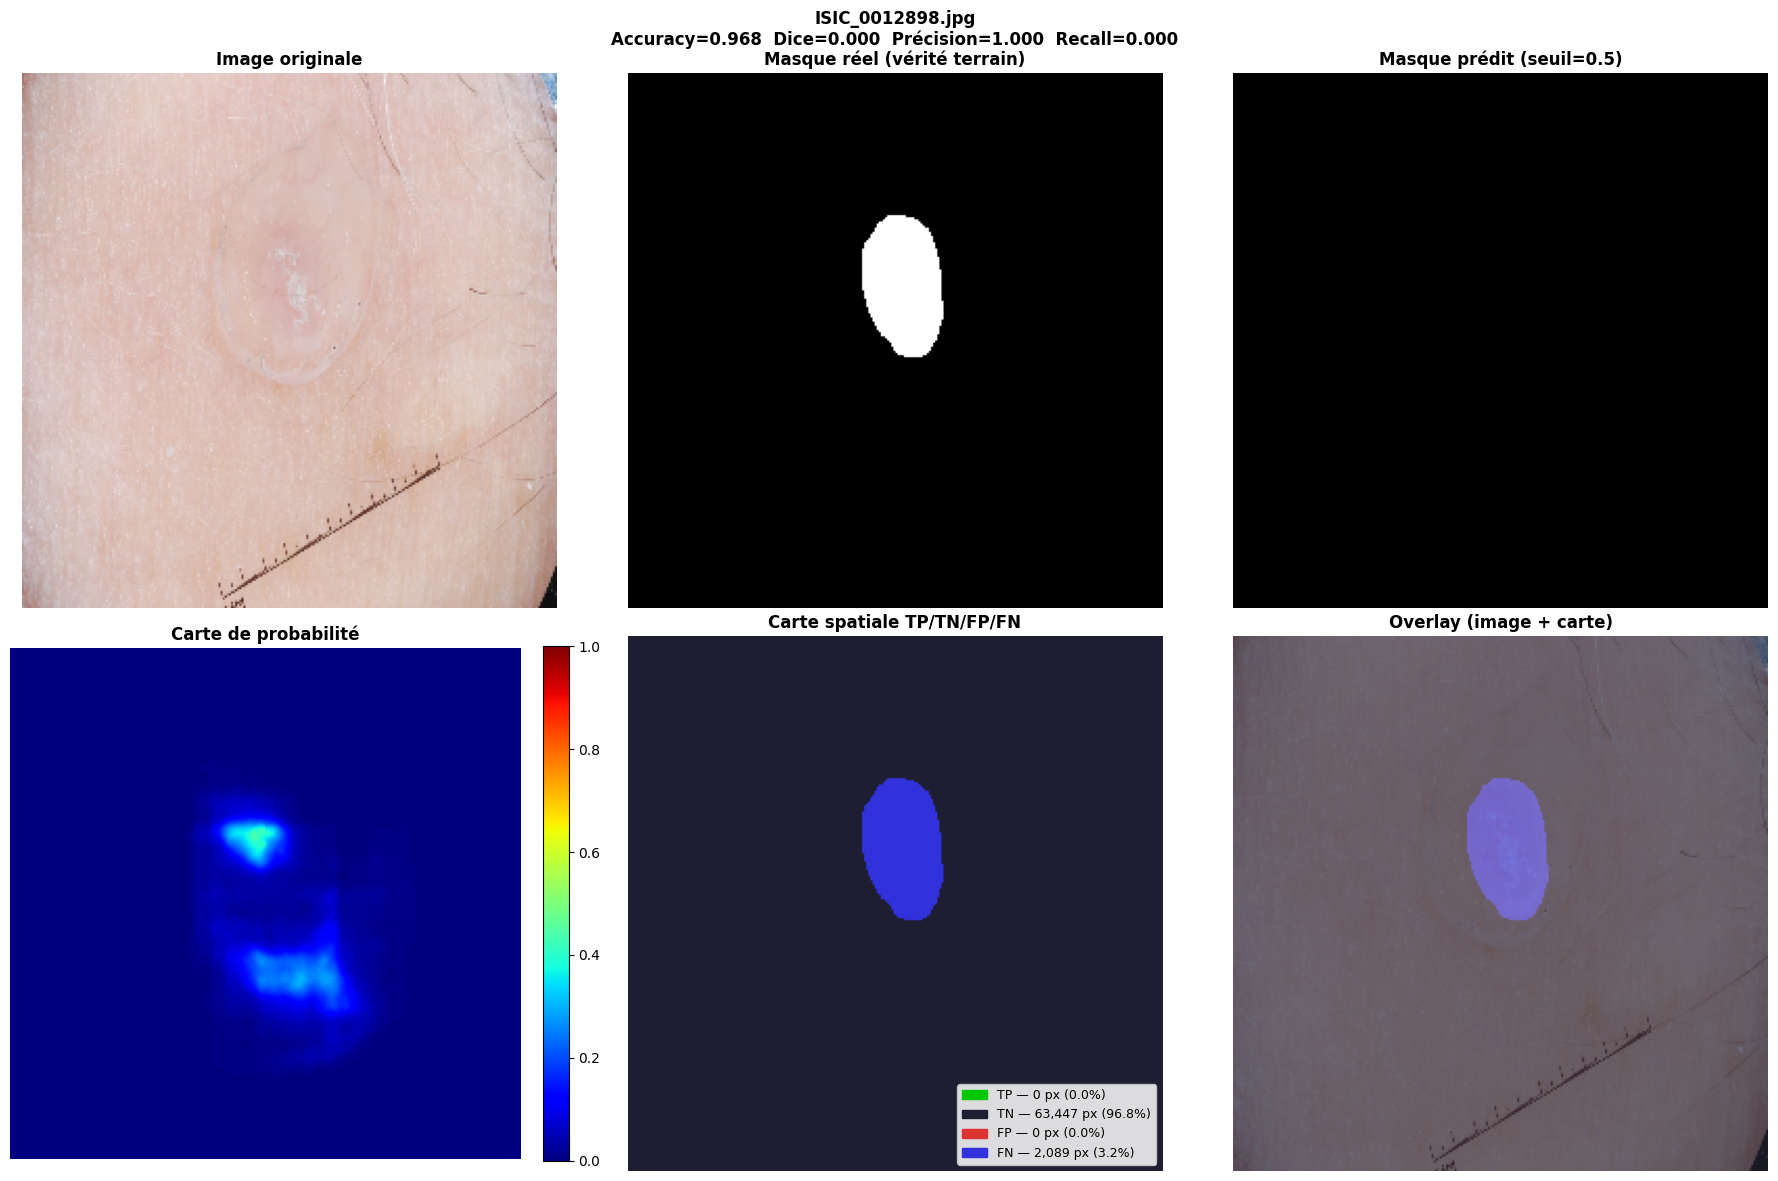


🔲 Matrice de confusion — ISIC_0012898.jpg
              Réalité Lésion  │  Réalité Sain
  Prédit Lésion           0   │           0
  Prédit Sain         2,089   │      63,447


{'tp': np.int64(0),
 'tn': np.int64(63447),
 'fp': np.int64(0),
 'fn': np.int64(2089),
 'dice': np.float64(4.786979413696995e-10),
 'accuracy': np.float64(0.9681243896484375),
 'precision': np.float64(1.0),
 'recall': np.float64(4.786979413696995e-10)}

In [12]:
# 2. Pire prédiction (Dice le plus bas)
worst = per_image_cms[-1]
worst_idx = next(i for i, p in enumerate(test_imgs) if p.name == worst['filename'])

print('=' * 60)
print(f'❌ Cas difficile : {worst["filename"]}')
print(f'   Dice = {worst["dice"]:.4f}')
print('=' * 60)
visualize_spatial_cm(
    test_imgs[worst_idx], test_msks[worst_idx],
    save_path=os.path.join(CM_PATH, 'cm_spatial_difficile.png')
)

📊 Cas médian : ISIC_0001212.jpg
   Dice = 0.9188
💾 Sauvegardée : /content/drive/MyDrive/ISIC_Project/outputs/confusion_matrix/cm_spatial_median.png


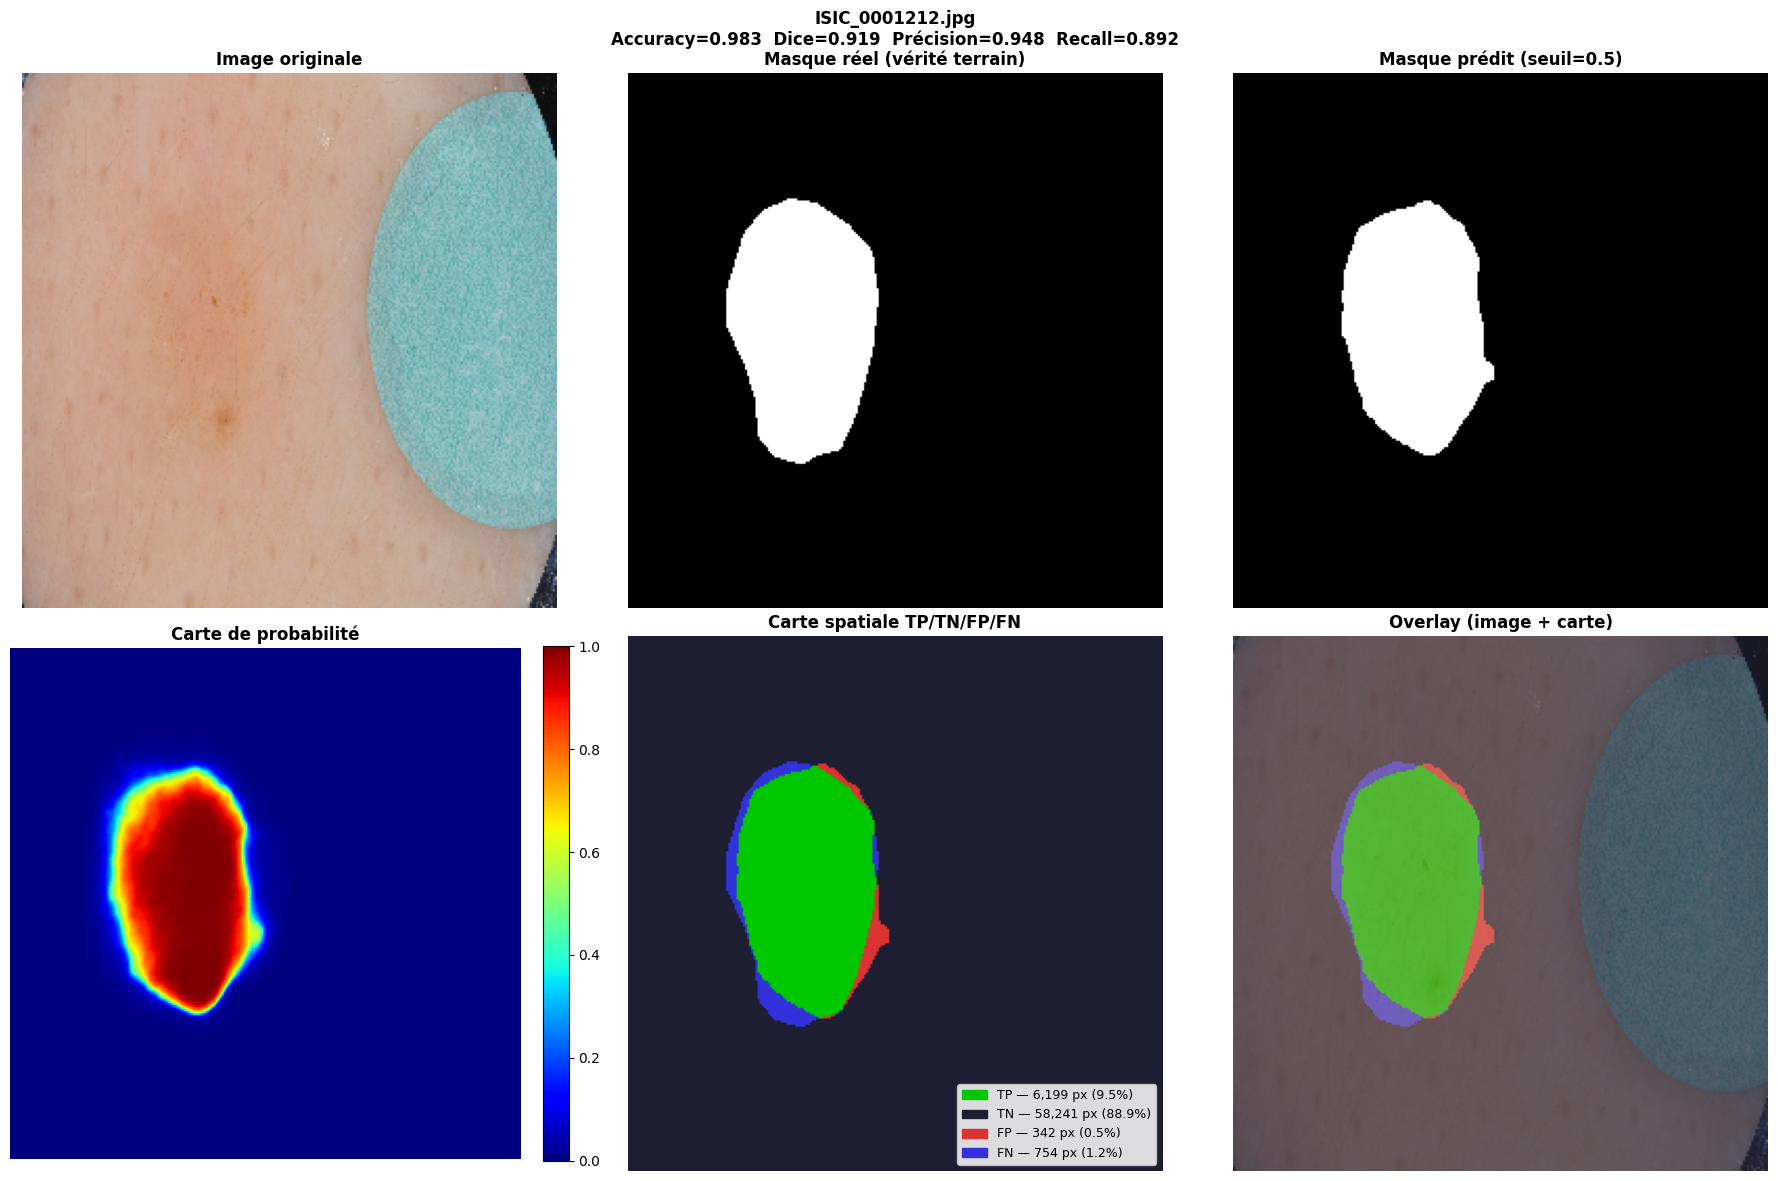


🔲 Matrice de confusion — ISIC_0001212.jpg
              Réalité Lésion  │  Réalité Sain
  Prédit Lésion       6,199   │         342
  Prédit Sain           754   │      58,241


{'tp': np.int64(6199),
 'tn': np.int64(58241),
 'fp': np.int64(342),
 'fn': np.int64(754),
 'dice': np.float64(0.9187787164725968),
 'accuracy': np.float64(0.9832763671875),
 'precision': np.float64(0.9477144167638413),
 'recall': np.float64(0.8915576010511207)}

In [13]:
# 3. Cas médian (Dice moyen)
mid_idx_list = len(per_image_cms) // 2
median_case  = per_image_cms[mid_idx_list]
med_idx = next(i for i, p in enumerate(test_imgs) if p.name == median_case['filename'])

print('=' * 60)
print(f'📊 Cas médian : {median_case["filename"]}')
print(f'   Dice = {median_case["dice"]:.4f}')
print('=' * 60)
visualize_spatial_cm(
    test_imgs[med_idx], test_msks[med_idx],
    save_path=os.path.join(CM_PATH, 'cm_spatial_median.png')
)

---
## 📊 Analyse globale des erreurs

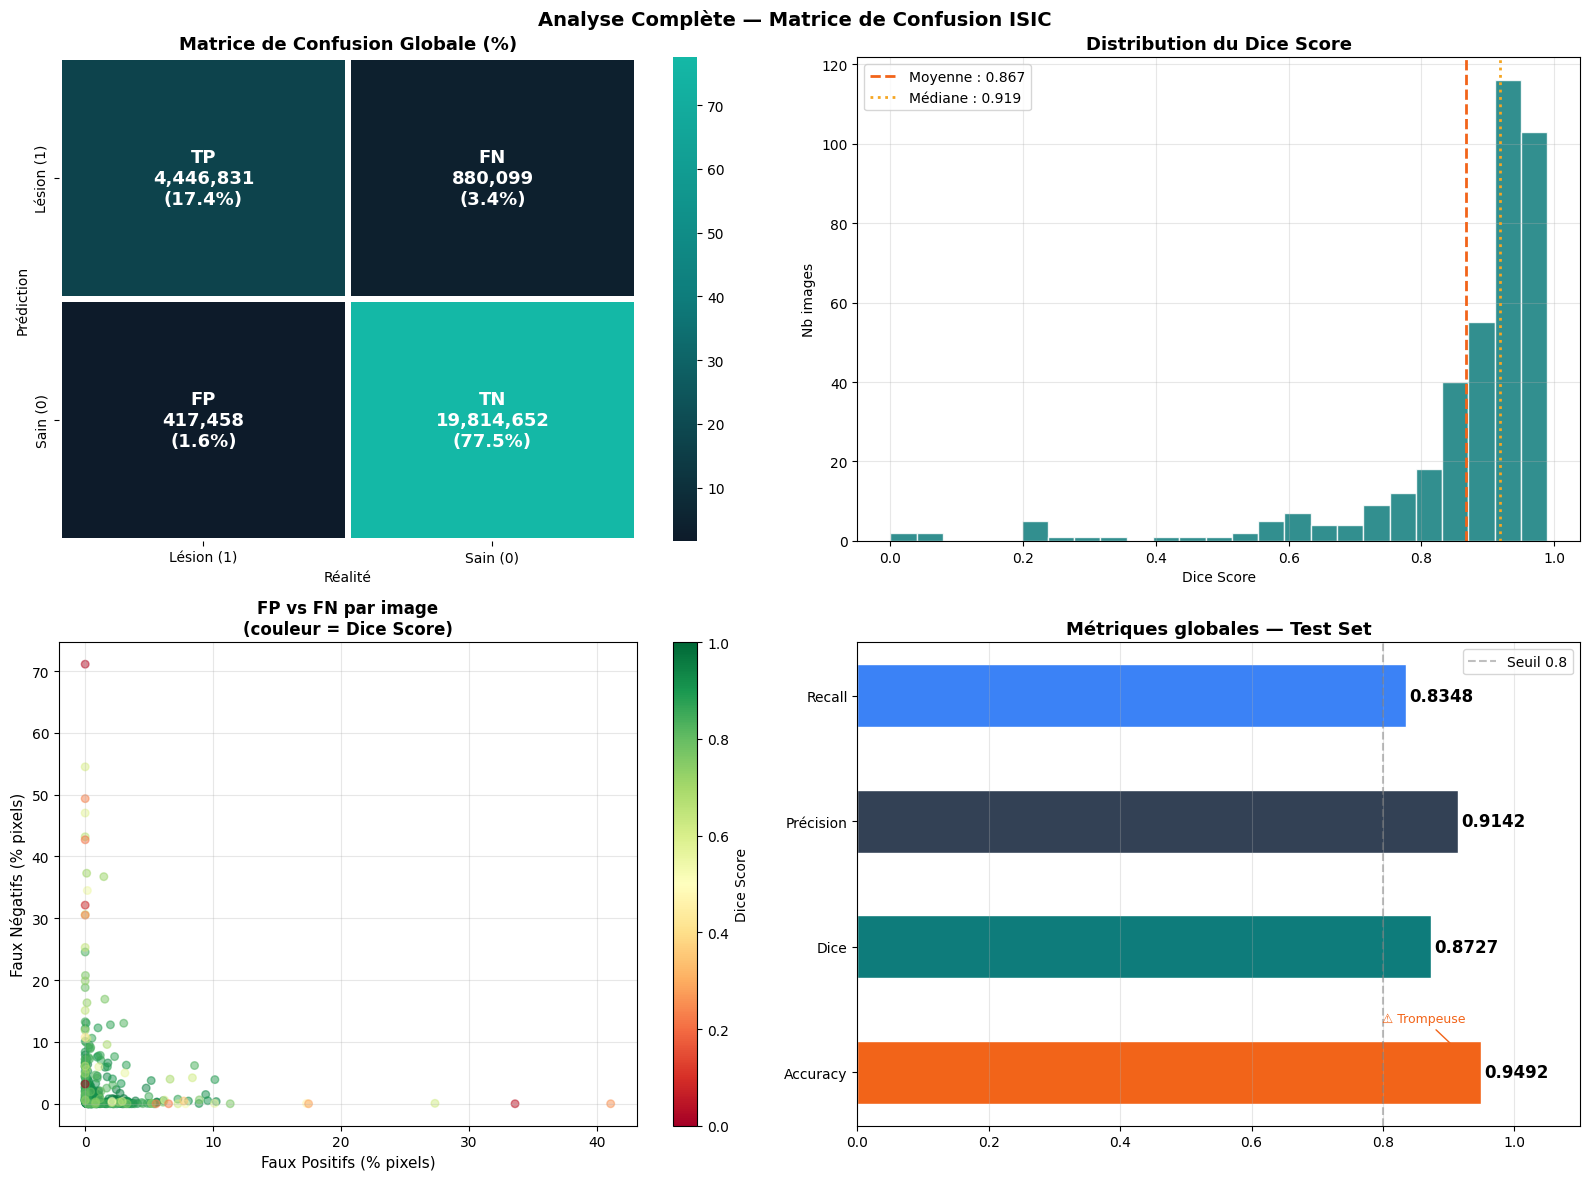

💾 Sauvegardée : /content/drive/MyDrive/ISIC_Project/outputs/confusion_matrix/analyse_confusion_complete.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. Matrice de confusion finale (belle version) ───────────────────────────
cm_final = np.array([[total_tp, total_fn],
                     [total_fp, total_tn]])
cm_norm  = cm_final / cm_final.sum() * 100

annot_labels = np.array([
    [f'TP\n{total_tp:,}\n({cm_norm[0,0]:.1f}%)', f'FN\n{total_fn:,}\n({cm_norm[0,1]:.1f}%)'],
    [f'FP\n{total_fp:,}\n({cm_norm[1,0]:.1f}%)', f'TN\n{total_tn:,}\n({cm_norm[1,1]:.1f}%)']
])
sns.heatmap(cm_norm, annot=annot_labels, fmt='',
            cmap=custom_cmap, ax=axes[0,0],
            linewidths=3, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'},
            xticklabels=['Lésion (1)', 'Sain (0)'],
            yticklabels=['Lésion (1)', 'Sain (0)'])
axes[0,0].set_title('Matrice de Confusion Globale (%)', fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Réalité'); axes[0,0].set_ylabel('Prédiction')

# ── 2. Distribution du Dice Score ────────────────────────────────────────────
dice_scores = [r['dice'] for r in per_image_cms]
axes[0,1].hist(dice_scores, bins=25, color='#0E7C7B', edgecolor='white', alpha=0.85)
axes[0,1].axvline(np.mean(dice_scores), color='#F26419', lw=2, linestyle='--',
                   label=f'Moyenne : {np.mean(dice_scores):.3f}')
axes[0,1].axvline(np.median(dice_scores), color='#F5A623', lw=2, linestyle=':',
                   label=f'Médiane : {np.median(dice_scores):.3f}')
axes[0,1].set_title('Distribution du Dice Score', fontweight='bold', fontsize=13)
axes[0,1].set_xlabel('Dice Score'); axes[0,1].set_ylabel('Nb images')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# ── 3. FP vs FN par image ────────────────────────────────────────────────────
fp_pcts = [r['fp']/(r['tp']+r['tn']+r['fp']+r['fn'])*100 for r in per_image_cms]
fn_pcts = [r['fn']/(r['tp']+r['tn']+r['fp']+r['fn'])*100 for r in per_image_cms]
axes[1,0].scatter(fp_pcts, fn_pcts, alpha=0.5, c=dice_scores,
                  cmap='RdYlGn', s=30, vmin=0, vmax=1)
axes[1,0].set_xlabel('Faux Positifs (% pixels)', fontsize=11)
axes[1,0].set_ylabel('Faux Négatifs (% pixels)', fontsize=11)
axes[1,0].set_title('FP vs FN par image\n(couleur = Dice Score)', fontweight='bold', fontsize=12)
axes[1,0].grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0,1))
plt.colorbar(sm, ax=axes[1,0], label='Dice Score')

# ── 4. Métriques moyennes (résumé) ───────────────────────────────────────────
metric_names = ['Accuracy', 'Dice', 'Précision', 'Recall']
metric_vals  = [accuracy, dice, precision, recall]
metric_colors= ['#F26419', '#0E7C7B', '#334155', '#3B82F6']
bars = axes[1,1].barh(metric_names, metric_vals, color=metric_colors,
                       edgecolor='white', height=0.5)
for bar, val in zip(bars, metric_vals):
    axes[1,1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{val:.4f}', va='center', fontsize=12, fontweight='bold')
axes[1,1].set_xlim(0, 1.1)
axes[1,1].axvline(0.8, color='gray', lw=1.5, linestyle='--', alpha=0.5, label='Seuil 0.8')
axes[1,1].set_title('Métriques globales — Test Set', fontweight='bold', fontsize=13)
axes[1,1].legend(); axes[1,1].grid(axis='x', alpha=0.3)
axes[1,1].annotate('⚠️ Trompeuse', xy=(accuracy, 0),
                    xytext=(accuracy-0.15, 0.4),
                    fontsize=9, color='#F26419',
                    arrowprops=dict(arrowstyle='->', color='#F26419'))

plt.suptitle('Analyse Complète — Matrice de Confusion ISIC',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(CM_PATH, 'analyse_confusion_complete.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Sauvegardée : {save_path}')

---
## 💾 Export JSON complet

In [15]:
export = {
    'global': {
        'tp': total_tp, 'tn': total_tn, 'fp': total_fp, 'fn': total_fn,
        'total_pixels': total_pixels,
        'accuracy': accuracy, 'dice': dice, 'iou': iou,
        'precision': precision, 'recall': recall, 'f1': f1,
        'specificity': specificity, 'fpr': fpr, 'fnr': fnr,
    },
    'per_image': per_image_cms
}

json_path = os.path.join(CM_PATH, 'confusion_matrix_data.json')
with open(json_path, 'w') as f:
    json.dump(export, f, indent=2, default=float)

print('\n✅ Export terminé !')
print(f'\n📁 Fichiers générés dans outputs/confusion_matrix/ :')
for f in sorted(os.listdir(CM_PATH)):
    size = os.path.getsize(os.path.join(CM_PATH, f)) / 1024
    print(f'   📄 {f:<45} ({size:.0f} KB)')

print(f'\n🔲 Résumé final :')
print(f'   TP = {total_tp:>12,}  (vrais positifs    — lésions bien détectées)')
print(f'   TN = {total_tn:>12,}  (vrais négatifs    — peau saine bien classée)')
print(f'   FP = {total_fp:>12,}  (faux positifs     — fausses alarmes)')
print(f'   FN = {total_fn:>12,}  (faux négatifs     — lésions manquées ⚠️)')
print(f'\n   Accuracy  = {accuracy:.4f}  ← gonflée par TN')
print(f'   Dice      = {dice:.4f}  ← métrique principale ⭐')


✅ Export terminé !

📁 Fichiers générés dans outputs/confusion_matrix/ :
   📄 analyse_confusion_complete.png                (241 KB)
   📄 cm_spatial_difficile.png                      (482 KB)
   📄 cm_spatial_median.png                         (530 KB)
   📄 cm_spatial_meilleure.png                      (496 KB)
   📄 confusion_matrix_data.json                    (116 KB)
   📄 confusion_matrix_globale.png                  (118 KB)
   📄 confusion_matrix_par_image.png                (251 KB)
   📄 confusion_matrix_tp_tn_fp_fn.png              (158 KB)

🔲 Résumé final :
   TP =    4,446,831  (vrais positifs    — lésions bien détectées)
   TN =   19,814,652  (vrais négatifs    — peau saine bien classée)
   FP =      417,458  (faux positifs     — fausses alarmes)
   FN =      880,099  (faux négatifs     — lésions manquées ⚠️)

   Accuracy  = 0.9492  ← gonflée par TN
   Dice      = 0.8727  ← métrique principale ⭐
